# Baseline — Random Forest con validación LOSO
Establece la métrica de referencia del proyecto.

In [1]:
import sys
sys.path.insert(0, "../src")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import h5py
import yaml
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              confusion_matrix, classification_report,
                              roc_curve, auc)
from sklearn.preprocessing import StandardScaler, label_binarize
from tqdm import tqdm

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})
COLORS = ["#1D9E75", "#534AB7", "#D85A30"]
RISK_LABELS = ["Bajo (0)", "Medio (1)", "Alto (2)"]

with open("../configs/default.yaml") as f:
    cfg = yaml.safe_load(f)

PROCESSED_H5 = Path(cfg["paths"]["processed"]) / "pamap2_features.h5"
FIGURES_DIR  = Path(cfg["paths"]["figures"])
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## 1. Carga del dataset

In [3]:
import os
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(project_root)
print(f"Directorio de trabajo: {project_root}")

Directorio de trabajo: D:\MAESTRÍA AI - UNI\IV SEMESTRE\PROYECTO DE INVESTIGACIÓN II\WORKSPACE_GIT\posture-risk-mining_by_Huaytalla


In [4]:
with h5py.File(PROCESSED_H5, "r") as f:
    X           = f["X"][:]
    y           = f["y"][:]
    subject_ids = f["subject_ids"][:]

X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
print(f"X: {X.shape} | y: {y.shape} | sujetos: {np.unique(subject_ids)}")

X: (194205, 297) | y: (194205,) | sujetos: [1 2 3 4 5 6 7 8 9]


## 2. Entrenamiento y evaluación LOSO

In [5]:
unique_subjects = np.unique(subject_ids)
rf_params       = cfg["baseline"]
n_classes       = len(np.unique(y))

fold_results  = []
all_y_true    = []
all_y_pred    = []
all_y_proba   = []

for test_sub in tqdm(unique_subjects, desc="LOSO"):
    train_mask = subject_ids != test_sub
    test_mask  = subject_ids == test_sub

    X_tr, y_tr = X[train_mask], y[train_mask]
    X_te, y_te = X[test_mask],  y[test_mask]

    scaler = StandardScaler()
    X_tr   = scaler.fit_transform(X_tr)
    X_te   = scaler.transform(X_te)

    clf = RandomForestClassifier(
        n_estimators=rf_params["n_estimators"],
        max_depth=rf_params["max_depth"],
        class_weight=rf_params["class_weight"],
        n_jobs=rf_params["n_jobs"],
        random_state=cfg["project"]["seed"],
    )
    clf.fit(X_tr, y_tr)
    y_pred  = clf.predict(X_te)
    y_proba = clf.predict_proba(X_te)

    acc  = accuracy_score(y_te, y_pred)
    f1   = f1_score(y_te, y_pred, average="macro", zero_division=0)
    y_bin = label_binarize(y_te, classes=list(range(n_classes)))
    try:
        auc_v = roc_auc_score(y_bin, y_proba, multi_class="ovr", average="macro")
    except Exception:
        auc_v = float("nan")

    fold_results.append({"subject": int(test_sub), "accuracy": acc, "f1_macro": f1, "auc_ovr": auc_v})
    all_y_true.extend(y_te.tolist())
    all_y_pred.extend(y_pred.tolist())
    all_y_proba.extend(y_proba.tolist())

all_y_true  = np.array(all_y_true)
all_y_pred  = np.array(all_y_pred)
all_y_proba = np.array(all_y_proba)

LOSO:  89%|█████████████████████████████████████████████████████████████████████▎        | 8/9 [12:14<01:36, 96.28s/it]C:\Users\jaime\miniconda3\Lib\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
LOSO: 100%|██████████████████████████████████████████████████████████████████████████████| 9/9 [14:14<00:00, 94.95s/it]


## 3. Tabla de métricas por fold

In [6]:
df_results = pd.DataFrame(fold_results)
print("\n=== MÉTRICAS POR FOLD (sujeto de prueba) ===")
print(df_results.to_string(index=False, float_format="%.4f"))

print("\n=== RESUMEN GLOBAL ===")
for metric in ["accuracy", "f1_macro", "auc_ovr"]:
    vals = df_results[metric].dropna()
    print(f"  {metric:15s}: {vals.mean():.4f} ± {vals.std():.4f}")

print("\n=== REPORTE DE CLASIFICACIÓN GLOBAL ===")
print(classification_report(all_y_true, all_y_pred, target_names=RISK_LABELS, zero_division=0))


=== MÉTRICAS POR FOLD (sujeto de prueba) ===
 subject  accuracy  f1_macro  auc_ovr
       1    0.8456    0.8409   0.9553
       2    0.8729    0.8694   0.9649
       3    0.8881    0.8596   0.9595
       4    0.8638    0.8604   0.9632
       5    0.8453    0.8440   0.9696
       6    0.8478    0.8433   0.9613
       7    0.8908    0.8944   0.9741
       8    0.9109    0.9076   0.9812
       9    0.5345    0.2322      NaN

=== RESUMEN GLOBAL ===
  accuracy       : 0.8333 ± 0.1144
  f1_macro       : 0.7946 ± 0.2122
  auc_ovr        : 0.9661 ± 0.0084

=== REPORTE DE CLASIFICACIÓN GLOBAL ===
              precision    recall  f1-score   support

    Bajo (0)       0.90      0.85      0.88     80613
   Medio (1)       0.86      0.89      0.87     67278
    Alto (2)       0.83      0.87      0.85     46314

    accuracy                           0.87    194205
   macro avg       0.86      0.87      0.87    194205
weighted avg       0.87      0.87      0.87    194205



## 4. Gráficas de desempeño del baseline

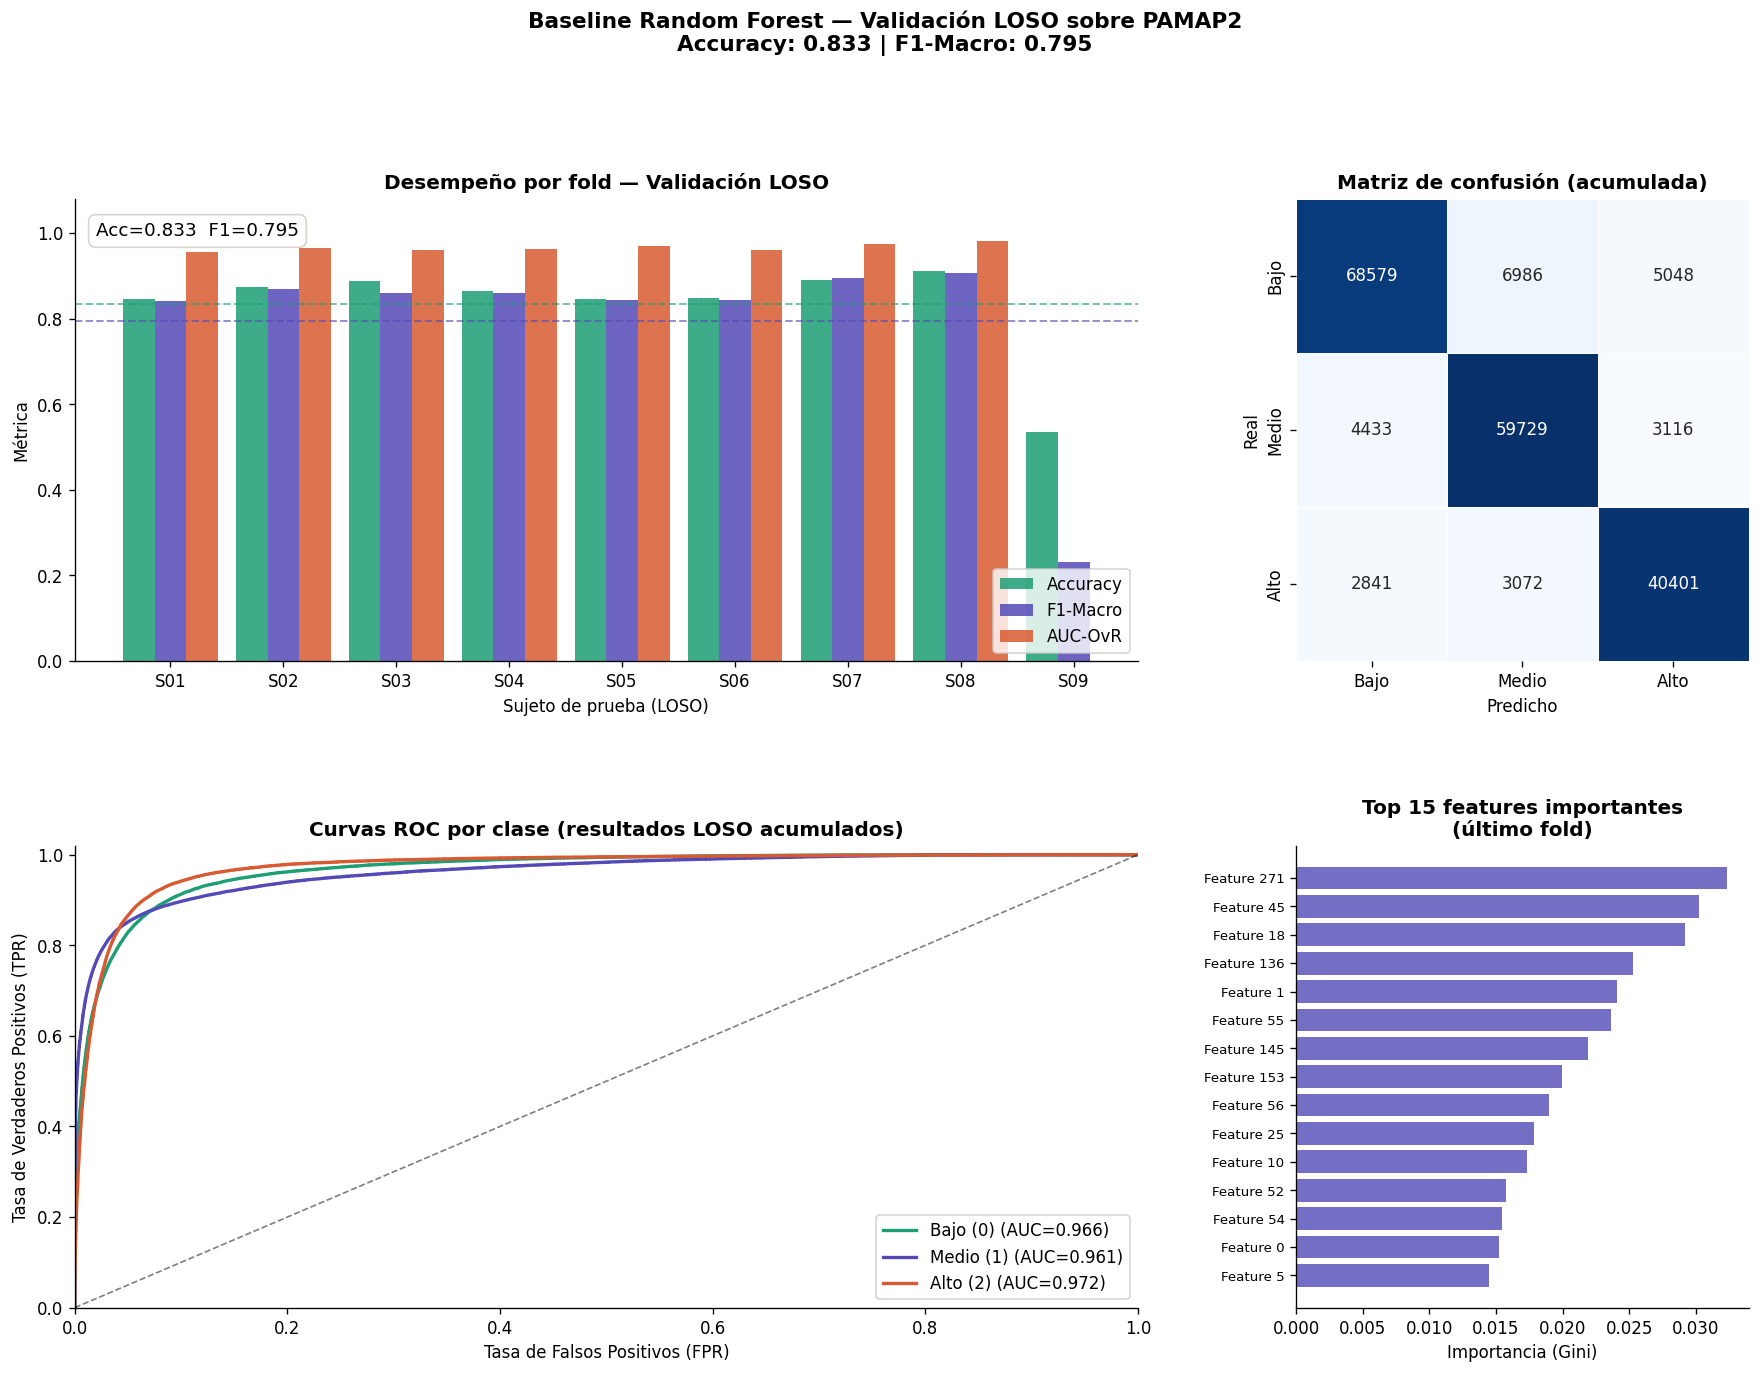


Figura guardada: reports\figures\04_baseline_results.png


In [7]:
fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# ─── Gráfica 1: Métricas por sujeto ──────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
subjects = df_results["subject"].values
x        = np.arange(len(subjects))
width    = 0.28

ax1.bar(x - width, df_results["accuracy"], width, label="Accuracy",  color=COLORS[0], alpha=0.85)
ax1.bar(x,         df_results["f1_macro"],  width, label="F1-Macro",  color=COLORS[1], alpha=0.85)
ax1.bar(x + width, df_results["auc_ovr"],   width, label="AUC-OvR",   color=COLORS[2], alpha=0.85)

ax1.axhline(df_results["accuracy"].mean(), color=COLORS[0], ls="--", lw=1.2, alpha=0.6)
ax1.axhline(df_results["f1_macro"].mean(),  color=COLORS[1], ls="--", lw=1.2, alpha=0.6)
ax1.set_xlabel("Sujeto de prueba (LOSO)")
ax1.set_ylabel("Métrica")
ax1.set_title("Desempeño por fold — Validación LOSO", fontweight="bold")
ax1.set_xticks(x)
ax1.set_xticklabels([f"S{s:02d}" for s in subjects])
ax1.set_ylim(0, 1.08)
ax1.legend(loc="lower right")

# Anotación de promedios
avg_acc = df_results["accuracy"].mean()
avg_f1  = df_results["f1_macro"].mean()
ax1.text(0.02, 0.95, f"Acc={avg_acc:.3f}  F1={avg_f1:.3f}",
         transform=ax1.transAxes, fontsize=11, va="top",
         bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="#D3D1C7", alpha=0.9))

# ─── Gráfica 2: Matriz de confusión acumulada ─────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
cm  = confusion_matrix(all_y_true, all_y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=cm, fmt="d", cmap="Blues",
            xticklabels=["Bajo", "Medio", "Alto"],
            yticklabels=["Bajo", "Medio", "Alto"],
            ax=ax2, cbar=False, linewidths=0.5)
ax2.set_title("Matriz de confusión (acumulada)", fontweight="bold")
ax2.set_xlabel("Predicho")
ax2.set_ylabel("Real")

# ─── Gráfica 3: Curvas ROC ────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, :2])
y_bin_all = label_binarize(all_y_true, classes=[0, 1, 2])
for i, (label, color) in enumerate(zip(RISK_LABELS, COLORS)):
    try:
        fpr, tpr, _ = roc_curve(y_bin_all[:, i], all_y_proba[:, i])
        roc_auc_v   = auc(fpr, tpr)
        ax3.plot(fpr, tpr, color=color, lw=2, label=f"{label} (AUC={roc_auc_v:.3f})")
    except Exception:
        pass
ax3.plot([0,1],[0,1], "k--", lw=1, alpha=0.5)
ax3.set_xlim([0, 1]); ax3.set_ylim([0, 1.02])
ax3.set_xlabel("Tasa de Falsos Positivos (FPR)")
ax3.set_ylabel("Tasa de Verdaderos Positivos (TPR)")
ax3.set_title("Curvas ROC por clase (resultados LOSO acumulados)", fontweight="bold")
ax3.legend(loc="lower right")

# ─── Gráfica 4: Importancia de features ──────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
# Último clf entrenado: importancias aproximadas del fold final
feat_imp = clf.feature_importances_
top_n    = 15
top_idx  = np.argsort(feat_imp)[-top_n:]
ax4.barh(range(top_n), feat_imp[top_idx], color=COLORS[1], alpha=0.8)
ax4.set_yticks(range(top_n))
ax4.set_yticklabels([f"Feature {i}" for i in top_idx], fontsize=8)
ax4.set_xlabel("Importancia (Gini)")
ax4.set_title(f"Top {top_n} features importantes\n(último fold)", fontweight="bold")

plt.suptitle(
    "Baseline Random Forest — Validación LOSO sobre PAMAP2\n"
    f"Accuracy: {avg_acc:.3f} | F1-Macro: {avg_f1:.3f}",
    fontsize=13, fontweight="bold", y=1.01
)
plt.savefig(FIGURES_DIR / "04_baseline_results.png", bbox_inches="tight", dpi=150)
plt.show()
print(f"\nFigura guardada: {FIGURES_DIR / '04_baseline_results.png'}")

## 5. Tabla resumen final de métricas

In [8]:
summary_df = pd.DataFrame({
    "Modelo": ["Random Forest (LOSO baseline)"],
    "Accuracy":  [f"{df_results['accuracy'].mean():.3f} ± {df_results['accuracy'].std():.3f}"],
    "F1-Macro":  [f"{df_results['f1_macro'].mean():.3f} ± {df_results['f1_macro'].std():.3f}"],
    "AUC-OvR":   [f"{df_results['auc_ovr'].mean():.3f} ± {df_results['auc_ovr'].std():.3f}"],
    "Validación":["LOSO (n=9 folds)"],
    "Dataset":   ["PAMAP2"],
})
print("\n=== TABLA RESUMEN ===")
print(summary_df.to_string(index=False))
summary_df.to_csv(FIGURES_DIR.parent / "baseline_summary.csv", index=False)
print("Tabla guardada en reports/baseline_summary.csv")


=== TABLA RESUMEN ===
                       Modelo      Accuracy      F1-Macro       AUC-OvR       Validación Dataset
Random Forest (LOSO baseline) 0.833 ± 0.114 0.795 ± 0.212 0.966 ± 0.008 LOSO (n=9 folds)  PAMAP2
Tabla guardada en reports/baseline_summary.csv
